In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# File load karein
df = pd.read_csv('creditcard.csv')

# Data ka overview
print("--- Data Shape ---")
print(df.shape)

print("\n--- First 5 Rows ---")
display(df.head())

print("\n--- Column Info ---")
print(df.info())

print("\n--- Checking for Missing Values ---")
print(df.isnull().sum().sum())
# 1. Missing values wali rows drop karein
df.dropna(inplace=True)

# 2. Re-check missing values (Check hona chahiye ke ab 0 hain)
print(f"Total Missing Values after cleaning: {df.isnull().sum().sum()}")

# 3. Class distribution (Fraud vs Normal)
print("\n--- Class Distribution ---")
print(df['Class'].value_counts())

# 4. Percentage check
fraud_pct = (df['Class'].value_counts()[1] / len(df)) * 100
print(f"\nFraud Percentage: {fraud_pct:.3f}%")

--- Data Shape ---
(213969, 31)

--- First 5 Rows ---


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0



--- Column Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 213969 entries, 0 to 213968
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    213969 non-null  float64
 1   V1      213969 non-null  float64
 2   V2      213969 non-null  float64
 3   V3      213969 non-null  float64
 4   V4      213969 non-null  float64
 5   V5      213969 non-null  float64
 6   V6      213968 non-null  float64
 7   V7      213968 non-null  float64
 8   V8      213968 non-null  float64
 9   V9      213968 non-null  float64
 10  V10     213968 non-null  float64
 11  V11     213968 non-null  float64
 12  V12     213968 non-null  float64
 13  V13     213968 non-null  float64
 14  V14     213968 non-null  float64
 15  V15     213968 non-null  float64
 16  V16     213968 non-null  float64
 17  V17     213968 non-null  float64
 18  V18     213968 non-null  float64
 19  V19     213968 non-null  float64
 20  V20     213968 non-null  fl

In [3]:
from sklearn.preprocessing import StandardScaler

# StandardScaler object banayein
scaler = StandardScaler()

# 'Amount' aur 'Time' ko scale karein
df['scaled_amount'] = scaler.fit_transform(df['Amount'].values.reshape(-1,1))
df['scaled_time'] = scaler.fit_transform(df['Time'].values.reshape(-1,1))

# Purane columns drop kar dein
df.drop(['Time', 'Amount'], axis=1, inplace=True)

print("Scaling complete! 'Amount' and 'Time' are now normalized.")
display(df.head())

Scaling complete! 'Amount' and 'Time' are now normalized.


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Class,scaled_amount,scaled_time
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0.0,0.238851,-2.013592
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0.0,-0.351958,-2.013592
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0.0,1.159825,-2.013565
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0.0,0.133822,-2.013565
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0.0,-0.081343,-2.013538


Transaction Counts:
Class
0.0    213570
1.0       398
Name: count, dtype: int64


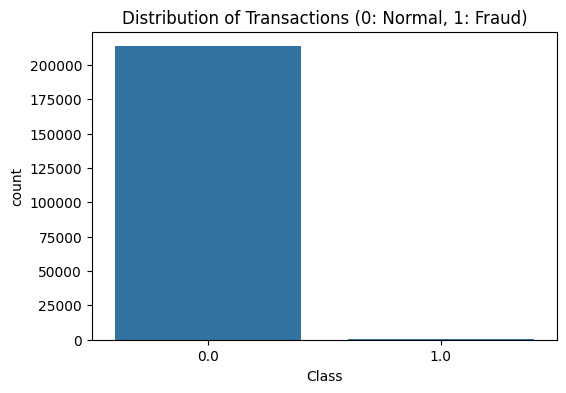

In [4]:
# Counting the classes
class_counts = df['Class'].value_counts()
print("Transaction Counts:")
print(class_counts)

# Visualization for GitHub (Recruiters love this!)
plt.figure(figsize=(6,4))
sns.countplot(x='Class', data=df)
plt.title('Distribution of Transactions (0: Normal, 1: Fraud)')
plt.show()

In [5]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

# 1. Split Features and Target
X = df.drop('Class', axis=1)
y = df['Class']

# 2. Train-Test Split (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Apply SMOTE to training data only
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print(f"Original training shape: {y_train.value_counts()}")
print(f"Resampled training shape: {y_train_res.value_counts()}")

Original training shape: Class
0.0    170854
1.0       320
Name: count, dtype: int64
Resampled training shape: Class
0.0    170854
1.0    170854
Name: count, dtype: int64


In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# 1. Model Initialize karein
# n_estimators=100 ka matlab hai hum 100 trees use kar rahe hain
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# 2. Resampled data par train karein
print("Training the model... (It might take a minute)")
rf_model.fit(X_train_res, y_train_res)

# 3. Predictions karein (Test data par jo model ne pehle nahi dekha)
y_pred = rf_model.predict(X_test)

print("Training Complete!")

Training the model... (It might take a minute)
Training Complete!



--- Confusion Matrix ---


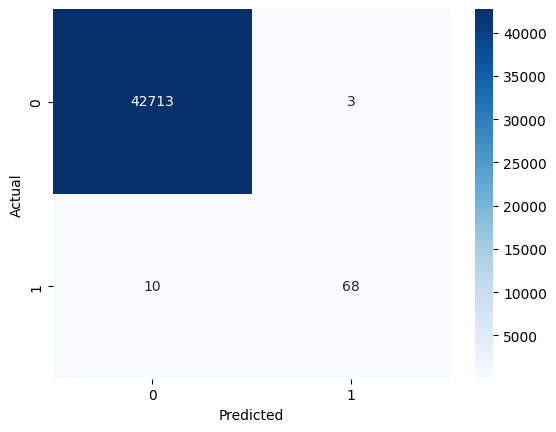


--- Classification Report ---
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     42716
         1.0       0.96      0.87      0.91        78

    accuracy                           1.00     42794
   macro avg       0.98      0.94      0.96     42794
weighted avg       1.00      1.00      1.00     42794



In [7]:
# Confusion Matrix print karein
print("\n--- Confusion Matrix ---")
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Classification Report
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

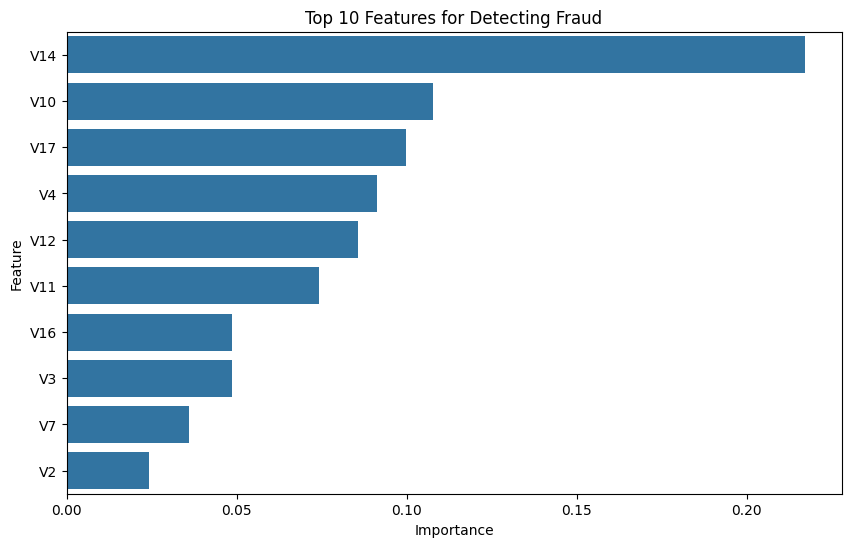

Model saved as 'fraud_model.pkl'. You can now use this in any app!


In [8]:
# 1. Feature Importance Chart
importances = rf_model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10))
plt.title('Top 10 Features for Detecting Fraud')
plt.show()

# 2. Save the Model (For Deployment)
import pickle
with open('fraud_model.pkl', 'wb') as file:
    pickle.dump(rf_model, file)

print("Model saved as 'fraud_model.pkl'. You can now use this in any app!")